# Technical validation of the provider-finalized reach package

The proposed design has two independent choices:

1. **VID outputs:** supply only the demographic VID output or supply both demographic and demographic-agnostic VID outputs.
2. **Reference-ID input:** do not use aggregate Reference-ID overlap or allow the provider's finalization function to use it.

Together they produce four input combinations:

| VID outputs supplied | Without Reference-ID overlap | With Reference-ID overlap |
|---|---|---|
| Demographic VID only | Provider instructions return the existing VID result | Provider instructions combine demographic VID aggregates with Reference-ID overlaps |
| Demographic and demographic-agnostic VID | Provider instructions may use either or both VID aggregate outputs | Provider instructions may use either or both VID aggregate outputs and Reference-ID overlaps |

The provider can train, select, and validate the full package because it has panel-person truth. It then publishes one explicit total-reach finalization function with the model line. The measurement-system operator runs the required VID model or models, computes approved aggregate Reference-ID intersections inside the TEE when needed, applies the frozen function, and enforces output bounds. Operator-side fitting is possible if the operator later obtains adequate truth, but it is not required by this design.

An **Event Data Provider (EDP)** is a publisher or other data source contributing campaign events. The VID labeler receives email and EDP-proprietary identifiers separately. The optional demographic-agnostic labeler can use a shared email as a direct cross-EDP VID anchor and may use objective, audience strategy, co-viewing, or other permitted context for proprietary-ID and ambiguous cases. Separately, the calibration workload derives a **Reference ID** from normalized email when available and otherwise from that EDP's proprietary identifier, hashed into a shared 5-billion-value space. Reference ID is not a VID-labeler input. “RID” is used only as a compact label in tables and charts.

In [1]:
from pathlib import Path
import csv
import json
import sys

from IPython.display import Image, Markdown, display


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run this notebook from the repository root or notebooks/.")


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, separator, *body])


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "panel_5000_final"

RUN_BENCHMARK = False
if RUN_BENCHMARK:
    from reference_calibration.panel_validation import run_panel_validation
    run_panel_validation(OUTPUT_DIR, profile="quick")

summary = json.loads((OUTPUT_DIR / "panel_validation_summary.json").read_text())
with (OUTPUT_DIR / "panel_validation_metrics.csv").open() as stream:
    metrics = list(csv.DictReader(stream))
with (OUTPUT_DIR / "panel_draws.csv").open() as stream:
    panel_draws = list(csv.DictReader(stream))
with (OUTPUT_DIR / "activation_decisions.csv").open() as stream:
    decisions = list(csv.DictReader(stream))
provider_packages = json.loads((OUTPUT_DIR / "provider_packages.json").read_text())

## 1. Information boundary and frozen artifacts

VID models are impression-level mappings. They receive email and EDP-proprietary identifiers as separate inputs. Depending on the approved design, the demographic-agnostic model may also use EDP, campaign objective, audience strategy, co-viewing, and other impression-available context when assigning VIDs for non-email cases. It does not receive the calibration Reference ID, report-level campaign size, or aggregate cross-EDP intersections.

The Reference-ID calibrator is not a third VID model. It is an optional part of a frozen finalization function that consumes aggregate report measurements. The provider can make that function use either VID output, both VID outputs, Reference-ID overlap, or a validated combination of them. No person-level VID link between the two models—and no VID-to-Reference-ID link—is required.

A deployable provider package therefore contains whichever of the following are selected for a model line:

- the current demographic-ready VID model;
- the optional demographic-agnostic VID model;
- one provider-supplied total-reach finalization function, including any optional Reference-ID response and decoder instructions; and
- the demographic-adjustment instructions that map the selected total to the demographic-ready VID distribution.

In [2]:
package = provider_packages[0]


def finalization_summary(item):
    inputs = ", ".join(item["vid_inputs"])
    rid = "with Reference-ID overlap" if item["uses_reference_id"] else "without Reference-ID overlap"
    return f"{inputs}; {rid}"


display(Markdown(markdown_table(
    [
        {
            "item": "Agnostic VID labeler inputs",
            "value": ", ".join(package["vid_models"]["demographic_agnostic"]["identity_inputs"]),
        },
        {
            "item": "Reference ID used by labeler?",
            "value": str(package["vid_models"]["demographic_agnostic"]["uses_reference_id_calibration_input"]),
        },
        {
            "item": "Selected total-reach function",
            "value": finalization_summary(package["selected_total_reach_function"]),
        },
        {
            "item": "Person-level cross-model link used?",
            "value": str(package["selected_total_reach_function"]["uses_person_level_crosswalk"]),
        },
    ],
    [("item", "Frozen package item"), ("value", "Example value")],
)))

| Frozen package item | Example value |
|---|---|
| Agnostic VID labeler inputs | optional_normalized_email, optional_edp_proprietary_id |
| Reference ID used by labeler? | False |
| Selected total-reach function | demographic_vid, demographic_agnostic_vid; with Reference-ID overlap |
| Person-level cross-model link used? | False |

## 2. Synthetic training, selection, and evaluation flow

The experiment creates a large synthetic population with exact person-level truth. That truth is retained only by the test harness.

For each 5,000-person panel draw:

1. Train the email-first demographic-agnostic response on one group of campaigns, with email and proprietary identifiers kept separate and optional context used only for non-email behavior.
2. On a second group, learn an aggregate two-VID combiner and fit candidate Reference-ID response functions from weighted panel-person truth and aggregate panel Reference-ID intersections.
3. On a third group of whole campaigns, separately select a Reference-ID correction for the demographic-only and two-VID functions, or select identity for either path.
4. On the same held-out selection group, choose among the four input combinations, retaining existing VID unless an alternative clears the guardrails.
5. Freeze one total-reach finalization function and score it on a fourth, independent campaign group using full-population truth.

All splits are by campaign. Weekly snapshots from one campaign never appear in both fitting and validation data.

## 3. What the two-VID path represents

Reproducing a provider's proprietary impression-to-VID learner is outside this harness. Instead, the benchmark reconstructs the aggregate pair-duplication response that a frozen email-first agnostic model might produce.

For each EDP pair, observed shared-email overlap is treated as a direct VID anchor. A fitted response then estimates only the remaining overlap associated with proprietary identifiers, co-viewing, and other non-email cases, using EDP identities and optional objective or audience-strategy context. At report time, those pair relationships and the per-EDP reaches are combined into one valid multi-EDP audience. Ten EDPs require 45 pair responses plus pooled context effects, rather than 1,023 unrelated subset curves.

The provider must then turn the two VID outputs into one result. The synthetic implementation learns one number, an agnostic-model weight between zero and one. For every EDP pair, it blends the demographic-model and agnostic-model intersection estimates using that same weight, then reconstructs one valid multi-EDP audience. A weight of zero means the provider should use only the demographic model; a weight of one means it should use only the agnostic model; an interior value uses both.

This deliberately simple combiner is easy to inspect and requires only aggregate intersections from the two models. It does not link their person-level VIDs, link a VID to a calibration Reference ID, or claim that a production provider must use this exact one-parameter form. The agnostic-only result remains in the benchmark as a diagnostic, but the deployment comparison asks whether supplying both outputs improves the provider's final answer.

## 4. Campaign test matrix

The benchmark uses stylized versions of campaign objectives and audience tools available in products such as Meta Ads Manager. They are designed to cover distinct measurement mechanisms, not to estimate Meta's production audiences or match rates.

- **Campaign size** controls how much direct panel evidence is available.
- **Audience overlap across EDPs** controls how many of the same people are truly reached by multiple publishers.
- **Shared-email visibility** controls how much true duplication can be anchored directly by email in the agnostic VID model and, separately, how much appears in calibration Reference-ID intersections.

These properties are varied separately. This prevents the experiment from assuming that an objective name—such as “Sales”—automatically determines either true overlap or email matchability. Across the ten EDPs, base email availability ranges from 10% to 95% and the email-agreement parameter ranges from 52% to 72%, centered near 60%; the scenarios then select audiences with higher or lower matchability than that base population.

In [3]:
scenario_rows = []
for item in summary["scenario_descriptions"].values():
    scenario_rows.append({
        "objective": item["objective"],
        "setup": item["audience"],
        "size": item["volume"],
        "overlap": item["cross_edp_similarity"],
        "email": item["reference_matchability"],
        "purpose": item["intuition"],
    })
display(Markdown(markdown_table(
    scenario_rows,
    [
        ("objective", "Objective"),
        ("setup", "Real-world campaign setup"),
        ("size", "Relative size"),
        ("overlap", "Expected audience overlap across EDPs"),
        ("email", "Expected shared-email visibility"),
        ("purpose", "What the scenario tests"),
    ],
)))

| Objective | Real-world campaign setup | Relative size | Expected audience overlap across EDPs | Expected shared-email visibility | What the scenario tests |
|---|---|---|---|---|---|
| Awareness | Broad awareness delivery with few audience restrictions | Large | Low to moderate: each EDP reaches a broad but not identical audience | Typical for the general population | Control case: broad delivery is closest to the campaigns on which a conventional reach model is expected to work well. |
| Traffic | Interest targeting with click or landing-page optimization | Medium | Moderate: optimization can favor similar click-prone people | Typical; clicking does not require a shared email | Tests a campaign that is more selected than awareness but is not a direct retargeting audience. |
| Engagement | Engagement Custom Audience of prior video viewers or engagers | Small to medium | High: the same warm audience can be selected repeatedly | Slightly below typical; engagement does not require email | Tests high true duplication without assuming that the duplicated people are especially easy to match by email. |
| Leads | Instant Form, call, message, or signup optimization | Small | High: EDPs can converge on the same high-intent people | Above typical because lead actions often collect contact details | Tests a small conversion-oriented audience with both elevated duplication and elevated email visibility. |
| Sales | Prospecting optimized toward likely purchasers | Small to medium | High: optimization can converge on a shared pool of likely buyers | Moderately above typical | Tests algorithmic convergence on likely buyers without using a direct first-party retargeting list. |
| Sales | Website Custom Audience of recent visitors or cart viewers | Small | Very high: campaigns start from a similar first-party visitor pool | Above typical; some visitors log in, buy, or otherwise provide email | Tests the classic small retargeting case in which true cross-EDP overlap is much higher than a population-rate model expects. |
| Sales | Customer-list Custom Audience uploaded from CRM records | Very small | Very high: each EDP receives substantially the same seed list | Very high because the source audience is already email-rich | Tests the strongest upward matchability shift: a tiny audience selected from records that commonly include email. |
| Sales | Catalog retargeting or dynamic product ads | Small | High, but some EDP pairs share more products and users than others | Above typical | Tests stable pair-specific behavior rather than assuming every EDP combination matches equally well. |
| Sales | Lookalike audience built from a customer seed | Medium | Moderate to high: the same seed influences delivery, but the audience expands | Slightly above typical | Tests a middle ground between direct retargeting and broad prospecting. |
| Sales | Advantage+ audience expansion beyond the starting audience | Medium to large | Moderate: the starting signal is shared, but delivery broadens | Near typical after expansion | Tests whether a method handles a campaign that begins with a selected audience but expands toward broad delivery. |
| App promotion | App Activity Custom Audience of installers or in-app users | Small | High: the same app users can be retargeted repeatedly | Below typical when app identity is stronger than email identity | Tests high true duplication with a downward email-matchability shift—the opposite of a customer-list campaign. |
| Traffic | Different niche interests or exclusions at each EDP | Small | Low: the EDP audiences are intentionally different | Typical among the people who are reached | Negative control: the calibration should not invent duplicate reach merely because the campaigns are small. |
| Mixed | One report combining broad, traffic, lead, and retargeting campaigns | Mixed | Mixed by EDP | Mixed by EDP and audience source | Tests the realistic case in which a cross-media report combines campaigns with different objectives and audience construction. |

## 5. Provider-fitted Reference-ID candidates

The provider can observe, for panel campaigns, both weighted panel-person truth and aggregate Reference-ID intersections. That is enough to learn how much true overlap is visible through the common Reference ID without linking an existing VID to a Reference ID.

The benchmark fits three candidate families:

- **Fixed capture:** stable pair-specific visibility rates with no campaign-size term. This is easy to estimate and may transfer well when matching behavior is stable.
- **Fixed plus log scale:** pair-specific rates plus a pre-fitted logarithmic campaign-size effect. This can capture a smooth size relationship but may overfit or transfer poorly.
- **Two-group mixture:** a compact representation of people who are consistently easier or harder to match across EDPs. This can capture person-level correlation in email provision.

Each candidate uses observed pairwise, three-way, four-way, and higher-order panel intersections during fitting. At runtime, the current implementation estimates pairwise targets and infers higher orders through one internally consistent audience reconstruction (implemented here with maximum entropy). The result is one set of non-overlapping Venn regions, none of which can contain a negative audience.

The selected candidate is not merely a research conclusion. The provider publishes it as a frozen instruction bundle for the downstream measurement service: which base VID result to use, the fitted coefficients, how to subtract the 5B collision floor, how to decode a valid audience, the supported range, diagnostics, and the identity/fallback rule. The measurement service supplies the new report's aggregate VID and Reference-ID measurements to that bundle.

## 6. Panel designs

The raw panel size is fixed at 5,000. Effective size can be smaller when weights are unequal. Observable recruitment bias is corrected using known weights; hidden selection on intent and matchability is deliberately left uncorrected. The hidden-bias case is intentionally severe so the failure mode is visible, not a production prevalence estimate. This executed notebook uses four panel draws per condition, so its selection rates illustrate behavior rather than estimate stable production probabilities.

In [4]:
panel_rows = []
for design, item in summary["panel_designs"].items():
    panel_rows.append({
        "panel": item["label"],
        "raw": item["raw_size"],
        "mean_neff": f"{item['effective_size']['mean']:.0f}",
        "min_neff": f"{min(float(row['effective_size']) for row in panel_draws if row['panel_design'] == design):.0f}",
        "description": item["description"],
    })
display(Markdown(markdown_table(
    panel_rows,
    [("panel", "Panel"), ("raw", "Raw N"), ("mean_neff", "Mean effective N"), ("min_neff", "Minimum effective N"), ("description", "Purpose")],
)))

| Panel | Raw N | Mean effective N | Minimum effective N | Purpose |
|---|---|---|---|---|
| Representative panel | 5000 | 5000 | 5000 | A simple random panel. Its main limitation is sampling noise. |
| 5,000 members, lower effective size | 5000 | 1374 | 1190 | The panel has 5,000 members but unequal survey weights reduce the information content. |
| Observable bias, weighted | 5000 | 4455 | 4453 | Age and geography affect recruitment, and known selection weights correct most of the bias. |
| Hidden intent/matchability bias | 5000 | 4492 | 4485 | Recruitment also favors high-intent, email-matchable people; ordinary demographic weights cannot remove it. |

In [5]:
panel_truth_rows = []
band_labels = {
    "small_under_10_percent": "Small (<10%)",
    "medium_10_to_30_percent": "Medium (10%–30%)",
    "large_over_30_percent": "Large (>30%)",
}
for design, bands in summary["panel_truth_summary"].items():
    for band, result in bands.items():
        panel_truth_rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "volume": band_labels[band],
            "mean": f"{result['mean']:.2%}",
            "p90": f"{result['p90']:.2%}",
            "worst": f"{result['max']:.2%}",
        })
display(Markdown("### Panel-estimated truth versus full synthetic truth\n\n" + markdown_table(
    panel_truth_rows,
    [("panel", "Panel"), ("volume", "Volume"), ("mean", "Mean error"), ("p90", "p90"), ("worst", "Worst")],
)))

### Panel-estimated truth versus full synthetic truth

| Panel | Volume | Mean error | p90 | Worst |
|---|---|---|---|---|
| Representative panel | Small (<10%) | 3.37% | 6.88% | 20.00% |
| Representative panel | Medium (10%–30%) | 1.96% | 3.80% | 7.09% |
| Representative panel | Large (>30%) | 0.72% | 1.71% | 3.27% |
| 5,000 members, lower effective size | Small (<10%) | 10.52% | 19.60% | 43.31% |
| 5,000 members, lower effective size | Medium (10%–30%) | 5.79% | 11.03% | 24.40% |
| 5,000 members, lower effective size | Large (>30%) | 2.05% | 5.08% | 8.78% |
| Observable bias, weighted | Small (<10%) | 5.66% | 11.52% | 27.23% |
| Observable bias, weighted | Medium (10%–30%) | 3.40% | 7.63% | 15.24% |
| Observable bias, weighted | Large (>30%) | 1.66% | 4.02% | 5.60% |
| Hidden intent/matchability bias | Small (<10%) | 108.16% | 161.90% | 169.76% |
| Hidden intent/matchability bias | Medium (10%–30%) | 51.70% | 126.08% | 137.40% |
| Hidden intent/matchability bias | Large (>30%) | 19.86% | 46.02% | 58.87% |

## 7. Selection rule

Selection happens in two stages so the design answers two distinct questions.

First, for the demographic-only and two-VID functions separately, a Reference-ID family must:

- improve mean absolute relative error by at least 0.5 percentage points;
- avoid worsening p90 error by more than 0.5 percentage points; and
- show, after accounting for campaign-to-campaign variability, at least 90% confidence that its average error is lower.

If no family passes, that path uses its VID-only function—no Reference-ID correction.

Second, the provider applies the same guardrails to the four input combinations, always keeping existing VID as the fallback. This means the provider can recommend the demographic-only or two-VID function, with or without Reference-ID overlap.

In [6]:
configuration_labels = {
    "existing_vid": "Existing VID",
    "two_vid": "Both VID models",
    "existing_plus_selected_rid": "Existing VID + selected RID",
    "two_vid_plus_selected_rid": "Both VID models + selected RID",
}
activation_rows = []
for design, item in summary["activation_summary"].items():
    activation_rows.append({
        "panel": summary["panel_designs"][design]["label"],
        "existing_active": f"{item['existing_correction_active_rate']:.0%}",
        "existing_harm": f"{item['existing_correction_harm_rate']:.0%}",
        "two_vid_active": f"{item['two_vid_correction_active_rate']:.0%}",
        "two_vid_harm": f"{item['two_vid_correction_harm_rate']:.0%}",
        "agnostic_weight": f"{item['two_vid_agnostic_weight']['mean']:.0%}",
        "recommendations": ", ".join(
            f"{configuration_labels[name]}: {count}"
            for name, count in item["recommended_configuration_counts"].items()
            if count
        ),
    })
display(Markdown(markdown_table(
    activation_rows,
    [
        ("panel", "Panel"),
        ("existing_active", "RID active on existing"),
        ("existing_harm", "Existing-base activation harmed truth"),
        ("two_vid_active", "RID active on two-VID function"),
        ("two_vid_harm", "Two-VID activation harmed truth"),
        ("agnostic_weight", "Mean agnostic weight"),
        ("recommendations", "Complete configuration selected"),
    ],
)))

| Panel | RID active on existing | Existing-base activation harmed truth | RID active on two-VID function | Two-VID activation harmed truth | Mean agnostic weight | Complete configuration selected |
|---|---|---|---|---|---|---|
| Representative panel | 100% | 0% | 100% | 0% | 85% | Both VID models + selected RID: 4 |
| 5,000 members, lower effective size | 100% | 0% | 25% | 0% | 86% | Existing VID + selected RID: 4 |
| Observable bias, weighted | 100% | 0% | 50% | 0% | 87% | Existing VID + selected RID: 2, Both VID models + selected RID: 2 |
| Hidden intent/matchability bias | 0% | 0% | 0% | 0% | 100% | Existing VID: 4 |

## 8. Accuracy of the four input combinations

The table aggregates all independent evaluation campaigns and report shapes. The “selected RID” rows use the family chosen for that VID path, or the VID-only function if no family passed. The provider-recommended row uses the finalization function chosen on panel holdouts. The p90 and p99 columns are the error levels that 90% and 99% of tested reports are at or below. Relative error can exceed 100% when the true audience is small; a 140% error means the estimate missed by 1.4 times the true reach.

The existing-VID baseline is intentionally generated from a population-rate overlap assumption. It is almost exact for the broad-awareness control and can be severely wrong for narrow, correlated campaigns. These errors are useful for comparing methods inside the synthetic world, but they are not estimates of production VID accuracy.

“Provider recommended” is not a fifth alternative. It is the finalization function selected from the four input combinations in each panel draw.

| Panel | Configuration | Mean | p90 | p99 | Worst |
|---|---|---|---|---|---|
| Representative panel | Existing VID | 40.79% | 100.13% | 308.50% | 315.41% |
| Representative panel | Both VID models | 12.13% | 26.93% | 77.44% | 81.75% |
| Representative panel | Existing VID + selected RID | 8.56% | 17.06% | 98.52% | 100.20% |
| Representative panel | Both VID models + selected RID | 7.37% | 17.11% | 75.13% | 79.01% |
| Representative panel | Provider recommended | 7.37% | 17.11% | 75.13% | 79.01% |
| 5,000 members, lower effective size | Existing VID | 40.79% | 100.13% | 308.50% | 315.41% |
| 5,000 members, lower effective size | Both VID models | 11.79% | 25.38% | 74.54% | 81.05% |
| 5,000 members, lower effective size | Existing VID + selected RID | 8.43% | 17.61% | 93.90% | 102.86% |
| 5,000 members, lower effective size | Both VID models + selected RID | 11.11% | 23.61% | 76.38% | 81.05% |
| 5,000 members, lower effective size | Provider recommended | 8.43% | 17.61% | 93.90% | 102.86% |
| Observable bias, weighted | Existing VID | 40.79% | 100.13% | 308.50% | 315.41% |
| Observable bias, weighted | Both VID models | 11.72% | 25.22% | 73.83% | 79.96% |
| Observable bias, weighted | Existing VID + selected RID | 8.29% | 16.53% | 95.59% | 100.34% |
| Observable bias, weighted | Both VID models + selected RID | 9.49% | 21.45% | 72.32% | 78.56% |
| Observable bias, weighted | Provider recommended | 7.70% | 16.44% | 77.16% | 95.89% |
| Hidden intent/matchability bias | Existing VID | 40.79% | 100.13% | 308.50% | 315.41% |
| Hidden intent/matchability bias | Both VID models | 9.89% | 23.94% | 49.18% | 53.22% |
| Hidden intent/matchability bias | Existing VID + selected RID | 40.79% | 100.13% | 308.50% | 315.41% |
| Hidden intent/matchability bias | Both VID models + selected RID | 9.89% | 23.94% | 49.18% | 53.22% |
| Hidden intent/matchability bias | Provider recommended | 40.79% | 100.13% | 308.50% | 315.41% |

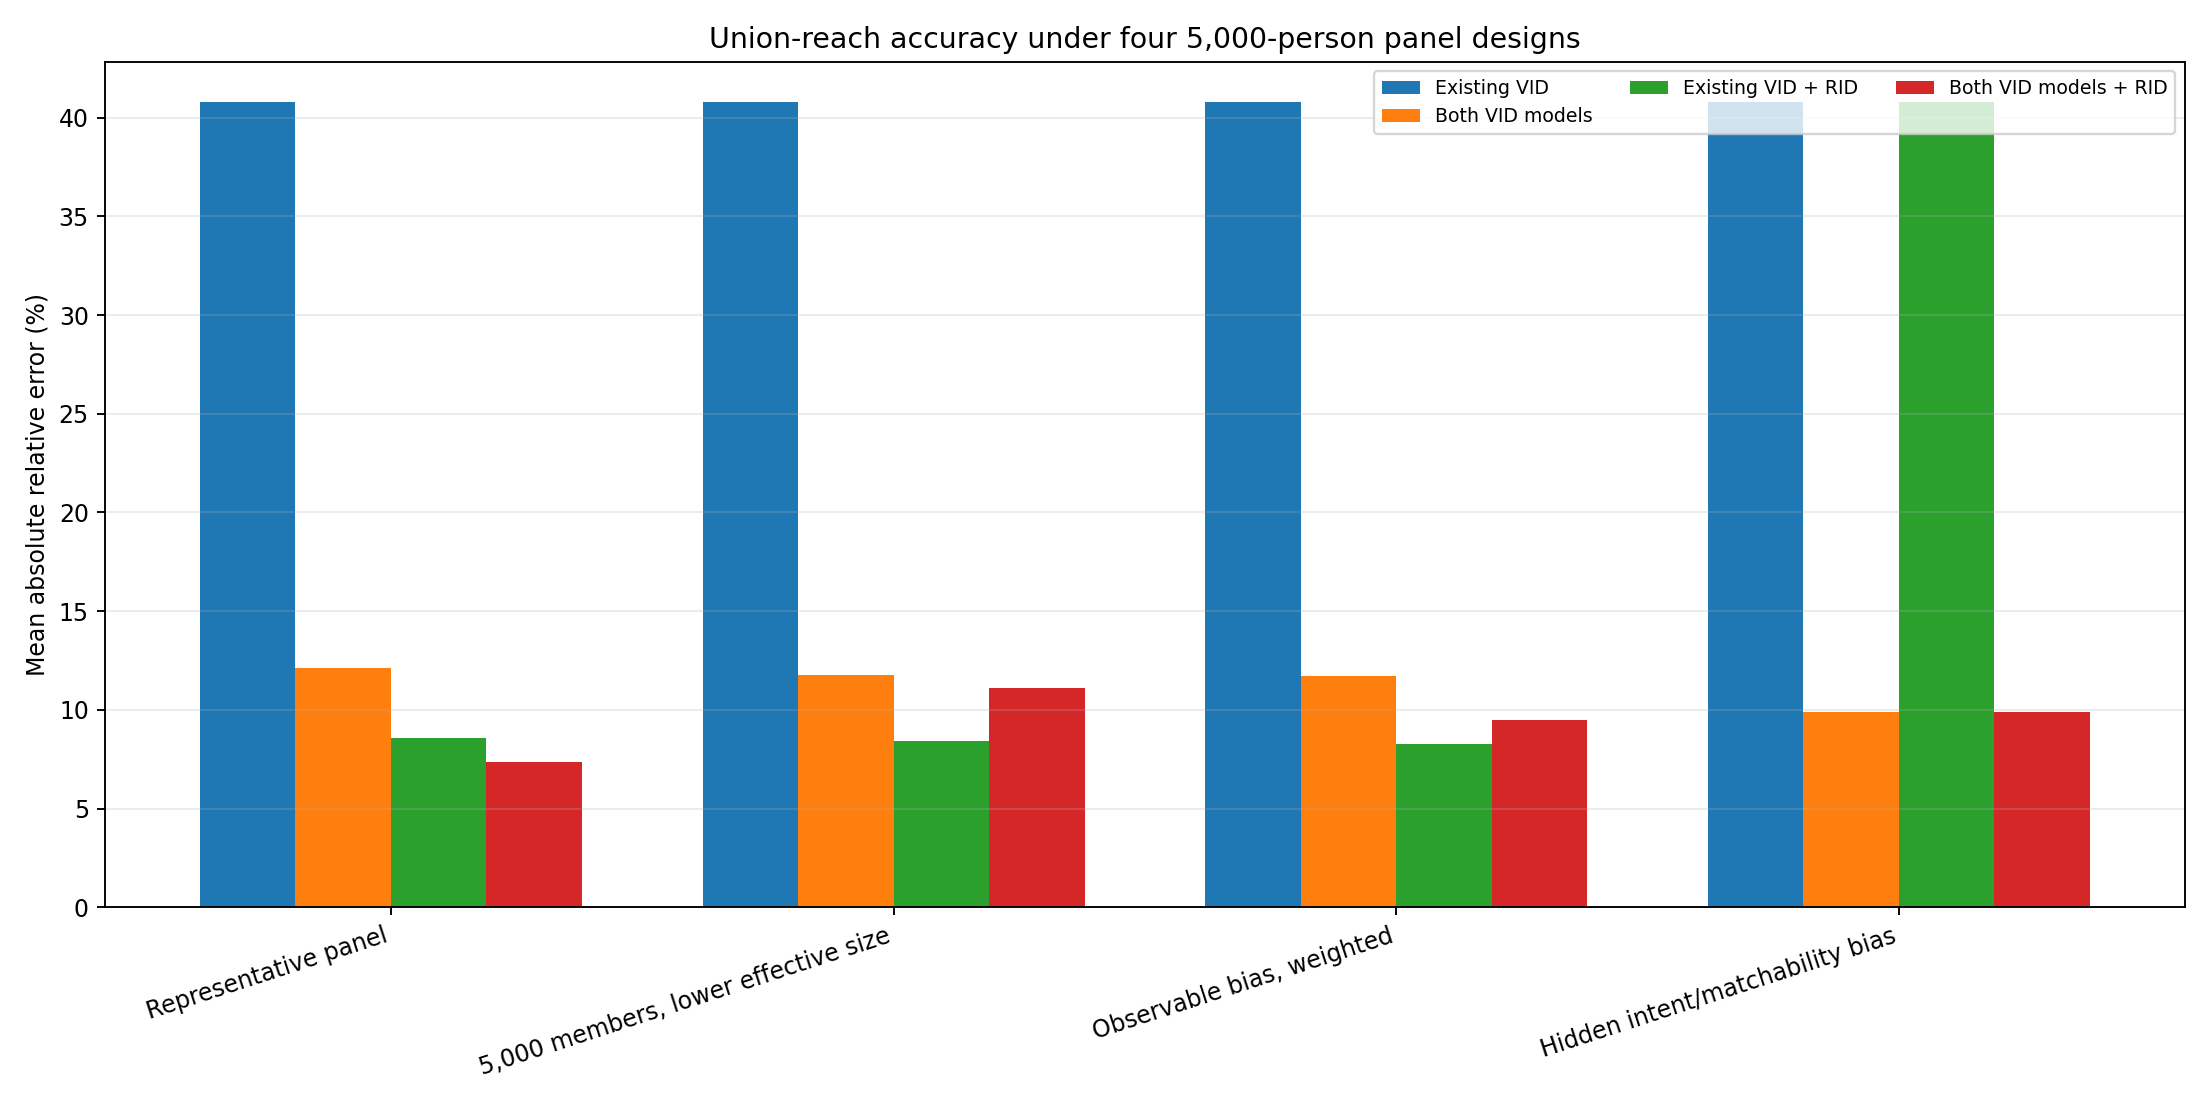

In [7]:
METHODS = [
    "existing_vid",
    "two_vid",
    "existing_plus_selected_rid",
    "two_vid_plus_selected_rid",
    "provider_recommended",
]
method_labels = {
    **configuration_labels,
    "provider_recommended": "Provider recommended",
}
rows = []
for design, values in summary["method_summary"].items():
    for method in METHODS:
        result = values[method]
        rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "method": method_labels[method],
            "mean": f"{result['mean']:.2%}",
            "p90": f"{result['p90']:.2%}",
            "p99": f"{result['p99']:.2%}",
            "max": f"{result['max']:.2%}",
        })
display(Markdown(markdown_table(
    rows,
    [("panel", "Panel"), ("method", "Configuration"), ("mean", "Mean"), ("p90", "p90"), ("p99", "p99"), ("max", "Worst")],
)))
display(Image(filename=str(OUTPUT_DIR / "error_by_panel_design.png")))

### Agnostic-only diagnostic

The two-VID deployment path may use either or both aggregate outputs. This harness tests one deliberately simple finalization function: a single bounded blend of the two models' pair-intersection estimates. The agnostic-only result below is retained as a diagnostic. When it beats the learned blend, the extra model contains useful information but the one-parameter combiner has not extracted all of it.

In [8]:
diagnostic_rows = []
for design, values in summary["method_summary"].items():
    diagnostic_rows.append({
        "panel": summary["panel_designs"][design]["label"],
        "agnostic": f"{values['agnostic_vid_diagnostic']['mean']:.2%}",
        "two_vid": f"{values['two_vid']['mean']:.2%}",
        "weight": f"{summary['activation_summary'][design]['two_vid_agnostic_weight']['mean']:.1%}",
    })
display(Markdown(markdown_table(
    diagnostic_rows,
    [
        ("panel", "Panel"),
        ("agnostic", "Agnostic-only error"),
        ("two_vid", "Two-VID function error"),
        ("weight", "Agnostic weight"),
    ],
)))

| Panel | Agnostic-only error | Two-VID function error | Agnostic weight |
|---|---|---|---|
| Representative panel | 9.91% | 12.13% | 84.7% |
| 5,000 members, lower effective size | 9.85% | 11.79% | 86.0% |
| Observable bias, weighted | 9.84% | 11.72% | 86.7% |
| Hidden intent/matchability bias | 9.89% | 9.89% | 100.0% |

In [9]:
hidden = summary["method_summary"]["hidden_matchability_bias"]
hidden_choice = summary["activation_summary"]["hidden_matchability_bias"]["recommended_configuration_counts"]
draw_count = sum(hidden_choice.values())
choice_text = ", ".join(
    f"**{method_labels[name]}** in {count} of {draw_count} draws"
    for name, count in hidden_choice.items()
    if count
)
display(Markdown(
    "**Hidden-bias stress result.** The panel selected "
    f"{choice_text}. The recommended configuration's full-population mean error was "
    f"**{hidden['provider_recommended']['mean']:.2%}**; for comparison, the two-VID function had "
    f"**{hidden['two_vid']['mean']:.2%}** error and the agnostic-only diagnostic had "
    f"**{hidden['agnostic_vid_diagnostic']['mean']:.2%}** error. The selection process behaved as designed; "
    "the panel was missing an important trait that affected the full population."
))

**Hidden-bias stress result.** The panel selected **Existing VID** in 4 of 4 draws. The recommended configuration's full-population mean error was **40.79%**; for comparison, the two-VID function had **9.89%** error and the agnostic-only diagnostic had **9.89%** error. The selection process behaved as designed; the panel was missing an important trait that affected the full population.

### Which correction family was selected for each VID path?

These counts are intentionally separate. A correction that helps the demographic VID model can be redundant or harmful after the two-VID function has already removed part of the same error.

In [10]:
family_rows = []
family_labels = {
    "existing_vid": "No correction",
    "two_vid": "No correction",
    "existing_plus_fixed": "Fixed capture",
    "two_vid_plus_fixed": "Fixed capture",
    "existing_plus_fixed_log": "Fixed + log size",
    "two_vid_plus_fixed_log": "Fixed + log size",
    "existing_plus_mixture": "Two-group mixture",
    "two_vid_plus_mixture": "Two-group mixture",
}
for design, item in summary["activation_summary"].items():
    family_rows.append({
        "panel": summary["panel_designs"][design]["label"],
        "existing": ", ".join(
            f"{family_labels[name]}: {count}" for name, count in item["existing_correction_selection_counts"].items() if count
        ),
        "two_vid": ", ".join(
            f"{family_labels[name]}: {count}" for name, count in item["two_vid_correction_selection_counts"].items() if count
        ),
    })
display(Markdown(markdown_table(
    family_rows,
    [("panel", "Panel"), ("existing", "Existing-VID selection"), ("two_vid", "Two-VID selection")],
)))

| Panel | Existing-VID selection | Two-VID selection |
|---|---|---|
| Representative panel | Fixed capture: 4 | Fixed capture: 1, Fixed + log size: 3 |
| 5,000 members, lower effective size | Fixed capture: 4 | No correction: 3, Two-group mixture: 1 |
| Observable bias, weighted | Fixed capture: 4 | No correction: 2, Fixed capture: 1, Fixed + log size: 1 |
| Hidden intent/matchability bias | No correction: 4 | No correction: 4 |

## 9. Interpreting the 5,000-person limit

For a simple random panel of effective size $N$, a rough relative 95% sampling interval for a reach proportion $p$ is:

$$
1.96\sqrt{p(1-p)/N}/p.
$$

This approximation ignores design effects and hidden selection bias, so it is optimistic for weighted or non-representative panels. Higher-order intersections are much sparser than single-EDP reach. If a true intersection is 0.02% of the population, a 5,000-person panel expects one matching person and has about a 37% chance of observing none.

The practical implication is that the panel should train and validate pooled behavior across many campaigns. It should not be treated as precise ground truth for every individual low-volume campaign.

In [11]:
sampling_rows = []
for proportion in (0.20, 0.10, 0.05, 0.01, 0.005, 0.002, 0.0002):
    expected = 5_000 * proportion
    relative = 1.96 * ((proportion * (1 - proportion) / 5_000) ** 0.5) / proportion
    zero = (1 - proportion) ** 5_000
    sampling_rows.append({
        "proportion": f"{proportion:.2%}",
        "expected": f"{expected:.1f}",
        "relative": f"±{relative:.0%}",
        "zero": f"{zero:.0%}",
    })
display(Markdown(markdown_table(
    sampling_rows,
    [("proportion", "Reach/intersection"), ("expected", "Expected panel people"), ("relative", "Approx. relative 95% interval"), ("zero", "Chance of zero observed")],
)))

| Reach/intersection | Expected panel people | Approx. relative 95% interval | Chance of zero observed |
|---|---|---|---|
| 20.00% | 1000.0 | ±6% | 0% |
| 10.00% | 500.0 | ±8% | 0% |
| 5.00% | 250.0 | ±12% | 0% |
| 1.00% | 50.0 | ±28% | 0% |
| 0.50% | 25.0 | ±39% | 0% |
| 0.20% | 10.0 | ±62% | 0% |
| 0.02% | 1.0 | ±196% | 37% |

## 10. Demographic adjustment is downstream of total reach

The measurement system always runs the demographic-ready model. When a different total is selected, the provider's demographic instruction adjusts that starting distribution so it adds to the selected total while respecting population limits.

The benchmark compares proportional scaling with a panel-learned contextual adjustment. Demographic-distribution error measures how far the reported shares differ from the true shares. Per-cell reach error also penalizes getting the total size of each demographic bucket wrong. Lower is better for both. Reference-ID overlaps supply no age, gender, or geography labels, so they cannot directly determine which demographic bucket changes.

In [12]:
demo_methods = (
    "existing_vid",
    "two_vid_proportional_demo",
    "two_vid_panel_demo",
    "existing_rid_panel_demo",
    "two_vid_rid_panel_demo",
    "recommended_panel_demo",
)
demo_labels = {
    "existing_vid": "Existing VID demographics",
    "two_vid_proportional_demo": "Two-VID total + proportional scaling",
    "two_vid_panel_demo": "Two-VID total + panel adjustment",
    "existing_rid_panel_demo": "Existing + RID + panel adjustment",
    "two_vid_rid_panel_demo": "Two-VID + RID + panel adjustment",
    "recommended_panel_demo": "Recommended total + panel adjustment",
}
demo_rows = []
for design in summary["panel_designs"]:
    for method in demo_methods:
        distribution_values = [
            float(row["value"])
            for row in metrics
            if row["panel_design"] == design
            and row["category"] == "demographic_distribution_error"
            and row["method"] == method
        ]
        reach_values = [
            float(row["value"])
            for row in metrics
            if row["panel_design"] == design
            and row["category"] == "demographic_reach_error"
            and row["method"] == method
        ]
        demo_rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "method": demo_labels[method],
            "distribution": f"{sum(distribution_values) / len(distribution_values):.2%}",
            "reach": f"{sum(reach_values) / len(reach_values):.2%}",
        })
display(Markdown(markdown_table(
    demo_rows,
    [("panel", "Panel"), ("method", "Demographic output"), ("distribution", "Distribution error"), ("reach", "Per-cell reach error")],
)))

| Panel | Demographic output | Distribution error | Per-cell reach error |
|---|---|---|---|
| Representative panel | Existing VID demographics | 6.38% | 43.29% |
| Representative panel | Two-VID total + proportional scaling | 6.37% | 17.91% |
| Representative panel | Two-VID total + panel adjustment | 4.14% | 15.45% |
| Representative panel | Existing + RID + panel adjustment | 4.12% | 13.20% |
| Representative panel | Two-VID + RID + panel adjustment | 4.15% | 11.76% |
| Representative panel | Recommended total + panel adjustment | 4.15% | 11.76% |
| 5,000 members, lower effective size | Existing VID demographics | 6.38% | 43.29% |
| 5,000 members, lower effective size | Two-VID total + proportional scaling | 6.37% | 17.76% |
| 5,000 members, lower effective size | Two-VID total + panel adjustment | 5.75% | 17.66% |
| 5,000 members, lower effective size | Existing + RID + panel adjustment | 5.74% | 15.81% |
| 5,000 members, lower effective size | Two-VID + RID + panel adjustment | 5.74% | 17.04% |
| 5,000 members, lower effective size | Recommended total + panel adjustment | 5.74% | 15.81% |
| Observable bias, weighted | Existing VID demographics | 6.38% | 43.29% |
| Observable bias, weighted | Two-VID total + proportional scaling | 6.37% | 17.67% |
| Observable bias, weighted | Two-VID total + panel adjustment | 4.47% | 15.52% |
| Observable bias, weighted | Existing + RID + panel adjustment | 4.45% | 13.52% |
| Observable bias, weighted | Two-VID + RID + panel adjustment | 4.47% | 13.74% |
| Observable bias, weighted | Recommended total + panel adjustment | 4.46% | 12.73% |
| Hidden intent/matchability bias | Existing VID demographics | 6.38% | 43.29% |
| Hidden intent/matchability bias | Two-VID total + proportional scaling | 6.37% | 16.93% |
| Hidden intent/matchability bias | Two-VID total + panel adjustment | 6.68% | 16.64% |
| Hidden intent/matchability bias | Existing + RID + panel adjustment | 7.48% | 46.02% |
| Hidden intent/matchability bias | Two-VID + RID + panel adjustment | 6.68% | 16.64% |
| Hidden intent/matchability bias | Recommended total + panel adjustment | 6.38% | 43.29% |

## 11. Cross-report consistency

Every configuration is tested on nested requests, including weeks 1–3 followed by weeks 1–12 and 2-, 5-, and 10-EDP subsets. The decoder guarantees a valid Venn diagram inside each report. It does not guarantee that reports calculated separately will agree wherever their weeks and EDPs overlap.

Freezing the model line and provider bundle makes a request reproducible without retrieving a prior result. Stored results are needed only when a new overlapping request must be checked against what has already been published. The raw violation rate below measures that remaining need for reconciliation.

In [13]:
consistency_rows = []
for design, item in summary["activation_summary"].items():
    consistency_rows.append({
        "panel": summary["panel_designs"][design]["label"],
        "violation_rate": f"{item['raw_consistency_violation_rate']:.2%}",
    })
display(Markdown(markdown_table(consistency_rows, [("panel", "Panel"), ("violation_rate", "Raw nested-report violation rate")])))

| Panel | Raw nested-report violation rate |
|---|---|
| Representative panel | 1.92% |
| 5,000 members, lower effective size | 1.92% |
| Observable bias, weighted | 1.92% |
| Hidden intent/matchability bias | 0.00% |

## 12. What this benchmark can and cannot establish

It establishes that all four input combinations can share one operator interface; that a provider can combine two VID aggregate outputs without linking their person-level identifiers; that optional correction can be learned from panel-only truth and aggregate Reference-ID observations; and that the resulting frozen package can be tested across 2-, 5-, and 10-EDP reports and varied week windows. It also quantifies sampling variability, panel-selection risk, correction-selection error, demographic allocation, and raw cross-report consistency in a controlled world.

It does not reproduce a provider's full production VID learner, prove that a real 5,000-person panel represents small retargeting or conversion audiences, or show that the synthetic winner will be the production winner. The hidden-bias experiment also shows a key limitation: a provider can make a statistically disciplined choice using its panel and still select the wrong configuration for the full population if the panel omits an important selection mechanism.

Production validation should therefore use repeated panel resampling, whole-campaign holdouts, results by campaign mechanism rather than one pooled score, and external truth where available. Shadow Reference-ID measurement remains useful for implementation checks and drift monitoring even when the provider supplies the initial bundle.